# Conectando com o GDrive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Importar o pandas

In [ ]:
import pandas as pd

## carregar o arquivo de Banco de dados.


In [ ]:
path ='/content/drive/MyDrive/processed.cleveland.data'



In [ ]:
df = pd.read_csv(path)

In [ ]:
# Mapeamento dos nomes das colunas originais (numéricos) para nomes mais descritivos
column_names = {
    '63.0': 'age', #idade
    '1.0': 'sex', #Sexo 1-Masculino e 2-Feminino
    '1.0.1': 'cp', #Dor no Peito 0: sem dor 1: angina típica 2: angina atípica 3:: dor não anginosa 4: assintomático
    '145.0': 'trestbps', #Pressão Arterial
    '233.0': 'chol', #colesterol sérico em mg
    '1.0.2': 'fbs', #fasting blood sugar / Clicemia em Jejum > 120mg/dl 1 true 0 false
    '2.0': 'restecg', #eletrocardiograma de repouso
    '150.0': 'thalach', #Frequência cardíaca máxima atingida
    '0.0': 'exang', #angina induzida pelo exercício (1 = sim; 0 = não)
    '2.3': 'oldpeak', #depressão do segmento ST induzida pelo exercício em relação ao repouso
    '3.0': 'slope', #inclinação do segmento ST no pico do exercício
    '0.0.1': 'ca', #número de grandes vasos (0-3) evidenciados por fluoroscopia
    '6.0': 'thal', #thal: 3 = normal; 6 = defeito fixo; 7 = defeito reversível
    '0': 'target' # A última coluna é o target
}

# Renomear as colunas do DataFrame
df.columns = [column_names.get(col, col) for col in df.columns]

display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0


In [ ]:
!head -n 5 {path}

63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
298,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
299,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
300,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1mpdhsRYpEmkDsgHY8XwKl1G8A2WGpcgfQsOKQkwWBiI/edit#gid=0


### Atualizando `X`, `y`, `features` e `target` com os novos nomes das colunas

In [ ]:
X = df.iloc[:, :-1]  # Todas as colunas, exceto a última, para features
y = df.iloc[:, -1]   # A última coluna para o target

In [ ]:
eatures = X.columns.tolist() # Obtém os nomes reais das colunas de X
target = y.name # Obtém o nome real da coluna target

In [ ]:
from sklearn import tree

model = tree.DecisionTreeClassifier(random_state=42)

In [ ]:
import numpy as np

# Substituir '?' por NaN em X
X = X.replace('?', np.nan)

# Converter X para tipo numérico e preencher NaNs com a média da coluna
X = X.astype(float)
X = X.fillna(X.mean())

# Treinar o modelo
model.fit(X,y)

DecisionTreeClassifier(random_state=42)

### Replotando a Árvore de Decisão com os Nomes das Colunas Atualizados

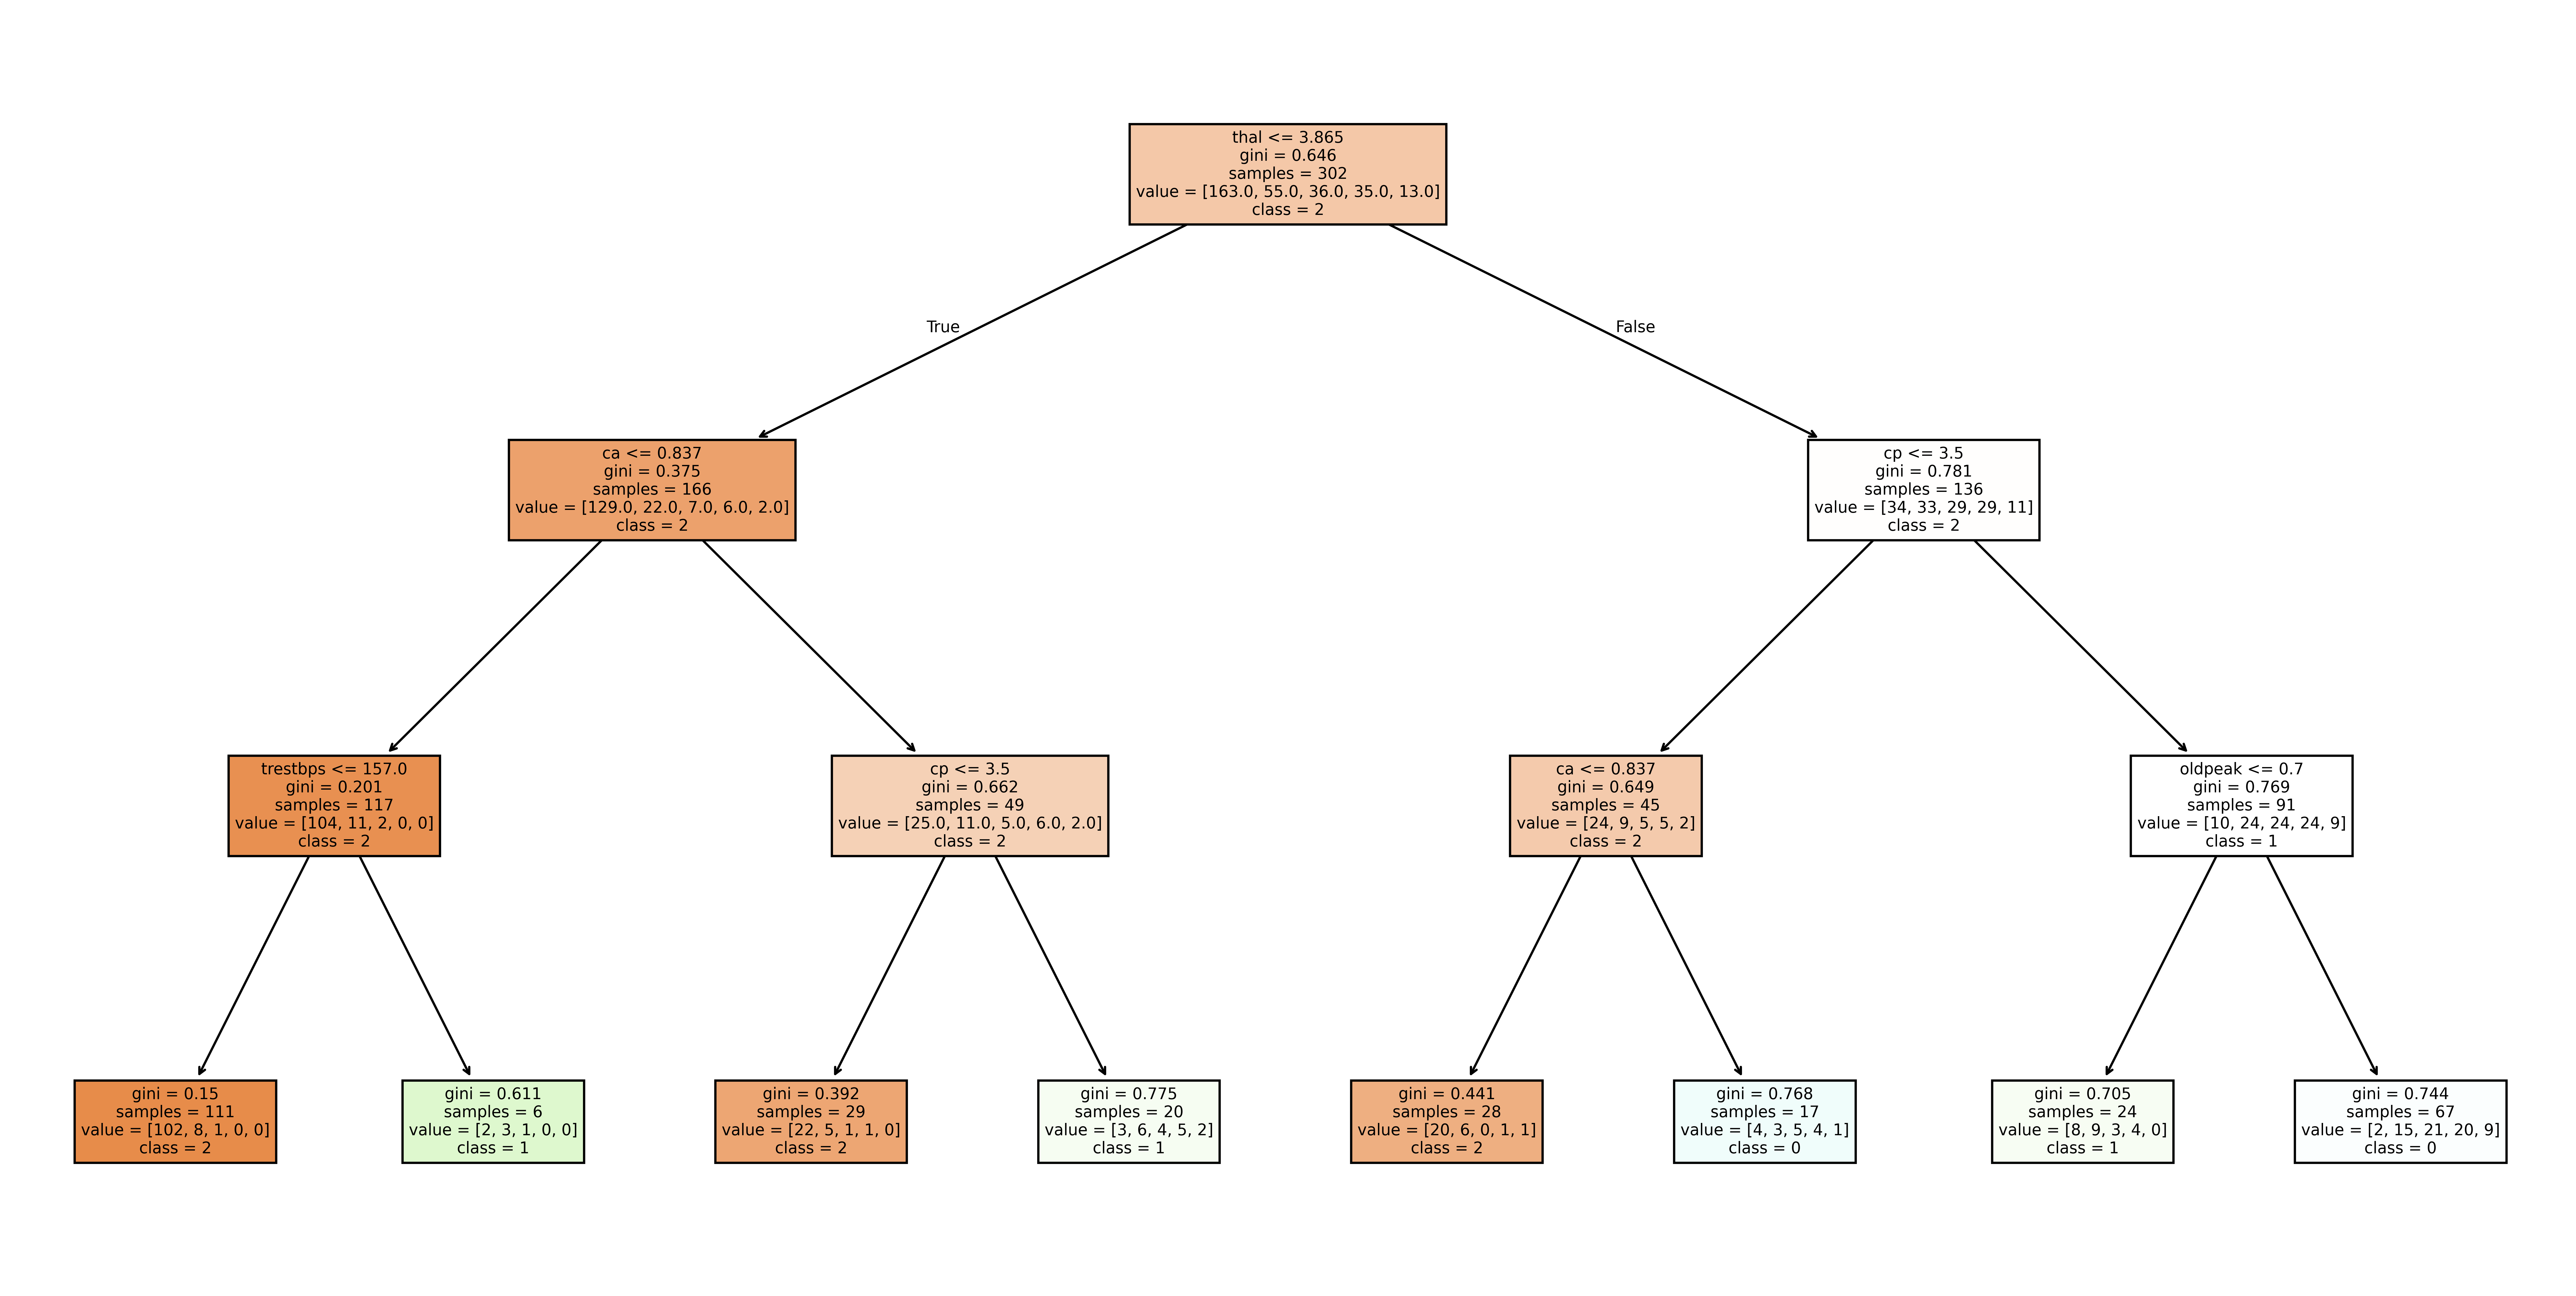

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree
import numpy as np # Importar numpy para usar np.nan
import pandas as pd # Importar pandas para ler o CSV

# --- Início das definições de df, X, y e features para autossuficiência --- #
# Definir o caminho do arquivo (replicado de aNpdAP3TmP78)
path ='/content/drive/MyDrive/processed.cleveland.data'

# Carregar o DataFrame (replicado de 4b0SKfPlmp-q)
df = pd.read_csv(path)

# Mapeamento dos nomes das colunas (replicado de e7358037)
column_names = {
    '63.0': 'age', #idade
    '1.0': 'sex', #Sexo 1-Masculino e 2-Feminino
    '1.0.1': 'cp', #Dor no Peito 0: sem dor 1: angina típica 2: angina atípica 3:: dor não anginosa 4: assintomático
    '145.0': 'trestbps', #Pressão Arterial
    '233.0': 'chol', #colesterol sérico em mg
    '1.0.2': 'fbs', #fasting blood sugar / Clicemia em Jejum > 120mg/dl 1 true 0 false
    '2.0': 'restecg', #eletrocardiograma de repouso
    '150.0': 'thalach', #Frequência cardíaca máxima atingida
    '0.0': 'exang', #angina induzida pelo exercício (1 = sim; 0 = não)
    '2.3': 'oldpeak', #depressão do segmento ST induzida pelo exercício em relação ao repouso
    '3.0': 'slope', #inclinação do segmento ST no pico do exercício
    '0.0.1': 'ca', #número de grandes vasos (0-3) evidenciados por fluoroscopia
    '6.0': 'thal', #thal: 3 = normal; 6 = defeito fixo; 7 = defeito reversível
    '0': 'target' # A última coluna é o target
}

# Renomear as colunas do DataFrame (replicado de e7358037)
df.columns = [column_names.get(col, col) for col in df.columns]

# Definir X e y (replicado de 6551bb02)
X = df.iloc[:, :-1]  # Todas as colunas, exceto a última, para features
y = df.iloc[:, -1]   # A última coluna para o target

# Definir 'features' para os nomes das colunas de X (replicado de 4b7625bd)
features = X.columns.tolist()
# --- Fim das definições de df, X, y e features --- #

# Redefine e treine o modelo dentro desta célula para garantir que esteja disponível.
# Isso corrige o 'NameError' caso o ambiente de execução tenha sido reiniciado
# ou as células de definição e treinamento do modelo não tenham sido executadas antes desta.
model = tree.DecisionTreeClassifier(random_state=42, max_depth=3)

# --- Início das etapas de limpeza de dados para X --- #
# É fundamental que X esteja limpo ANTES de treinar o modelo.
# Substituir '?' por NaN em X (se ainda houver)
X_cleaned = X.replace('?', np.nan)

# Converter X para tipo numérico (float) e preencher NaNs com a média da coluna
X_cleaned = X_cleaned.astype(float)
X_cleaned = X_cleaned.fillna(X_cleaned.mean())
# --- Fim das etapas de limpeza de dados para X --- #

model.fit(X_cleaned, y) # Treinar o modelo com a versão limpa de X

plt.figure(figsize=(20, 10), dpi=600)
tree.plot_tree(model, feature_names=features, class_names=[str(x) for x in y.unique()], filled=True)
plt.show()

# Separar y (target) e X (features)

# y => array

# X => matriz

In [ ]:
# As variáveis 'features' e 'target' são definidas aqui para serem usadas na visualização da árvore.
# Elas devem ser definidas APÓS X e y terem sido extraídos do DataFrame.
features = X.columns.tolist() # Obtém os nomes reais das colunas de X
target = y.name # Obtém o nome real da coluna target

In [ ]:
X = df.iloc[:, :-1]  # Todas as colunas, exceto a última, para features
y = df.iloc[:, -1]   # A última coluna para o target

In [ ]:
y

,target
0,2
1,1
2,0
3,0
4,0
...,...
297,1
298,2
299,3
300,1


In [ ]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0
298,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0
299,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0
300,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0


X

# criar o modelo (sklearn)

In [ ]:
from sklearn import tree

# Predição (predict)

In [ ]:
model = tree.DecisionTreeClassifier(random_state=42)

In [ ]:
import numpy as np

# Substituir '?' por NaN em X
X = X.replace('?', np.nan)

# Converter X para tipo numérico e preencher NaNs com a média da coluna
X = X.astype(float)
X = X.fillna(X.mean())

# Treinar o modelo
model.fit(X,y)

DecisionTreeClassifier(random_state=42)

In [ ]:
import pandas as pd

# Crie um DataFrame com os mesmos nomes de colunas (features) que X
prediction_input = pd.DataFrame([[1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1]], columns=features)

# Realize a previsão
model.predict(prediction_input)

array([2])

# Visualizar a árvore (matplotlib)

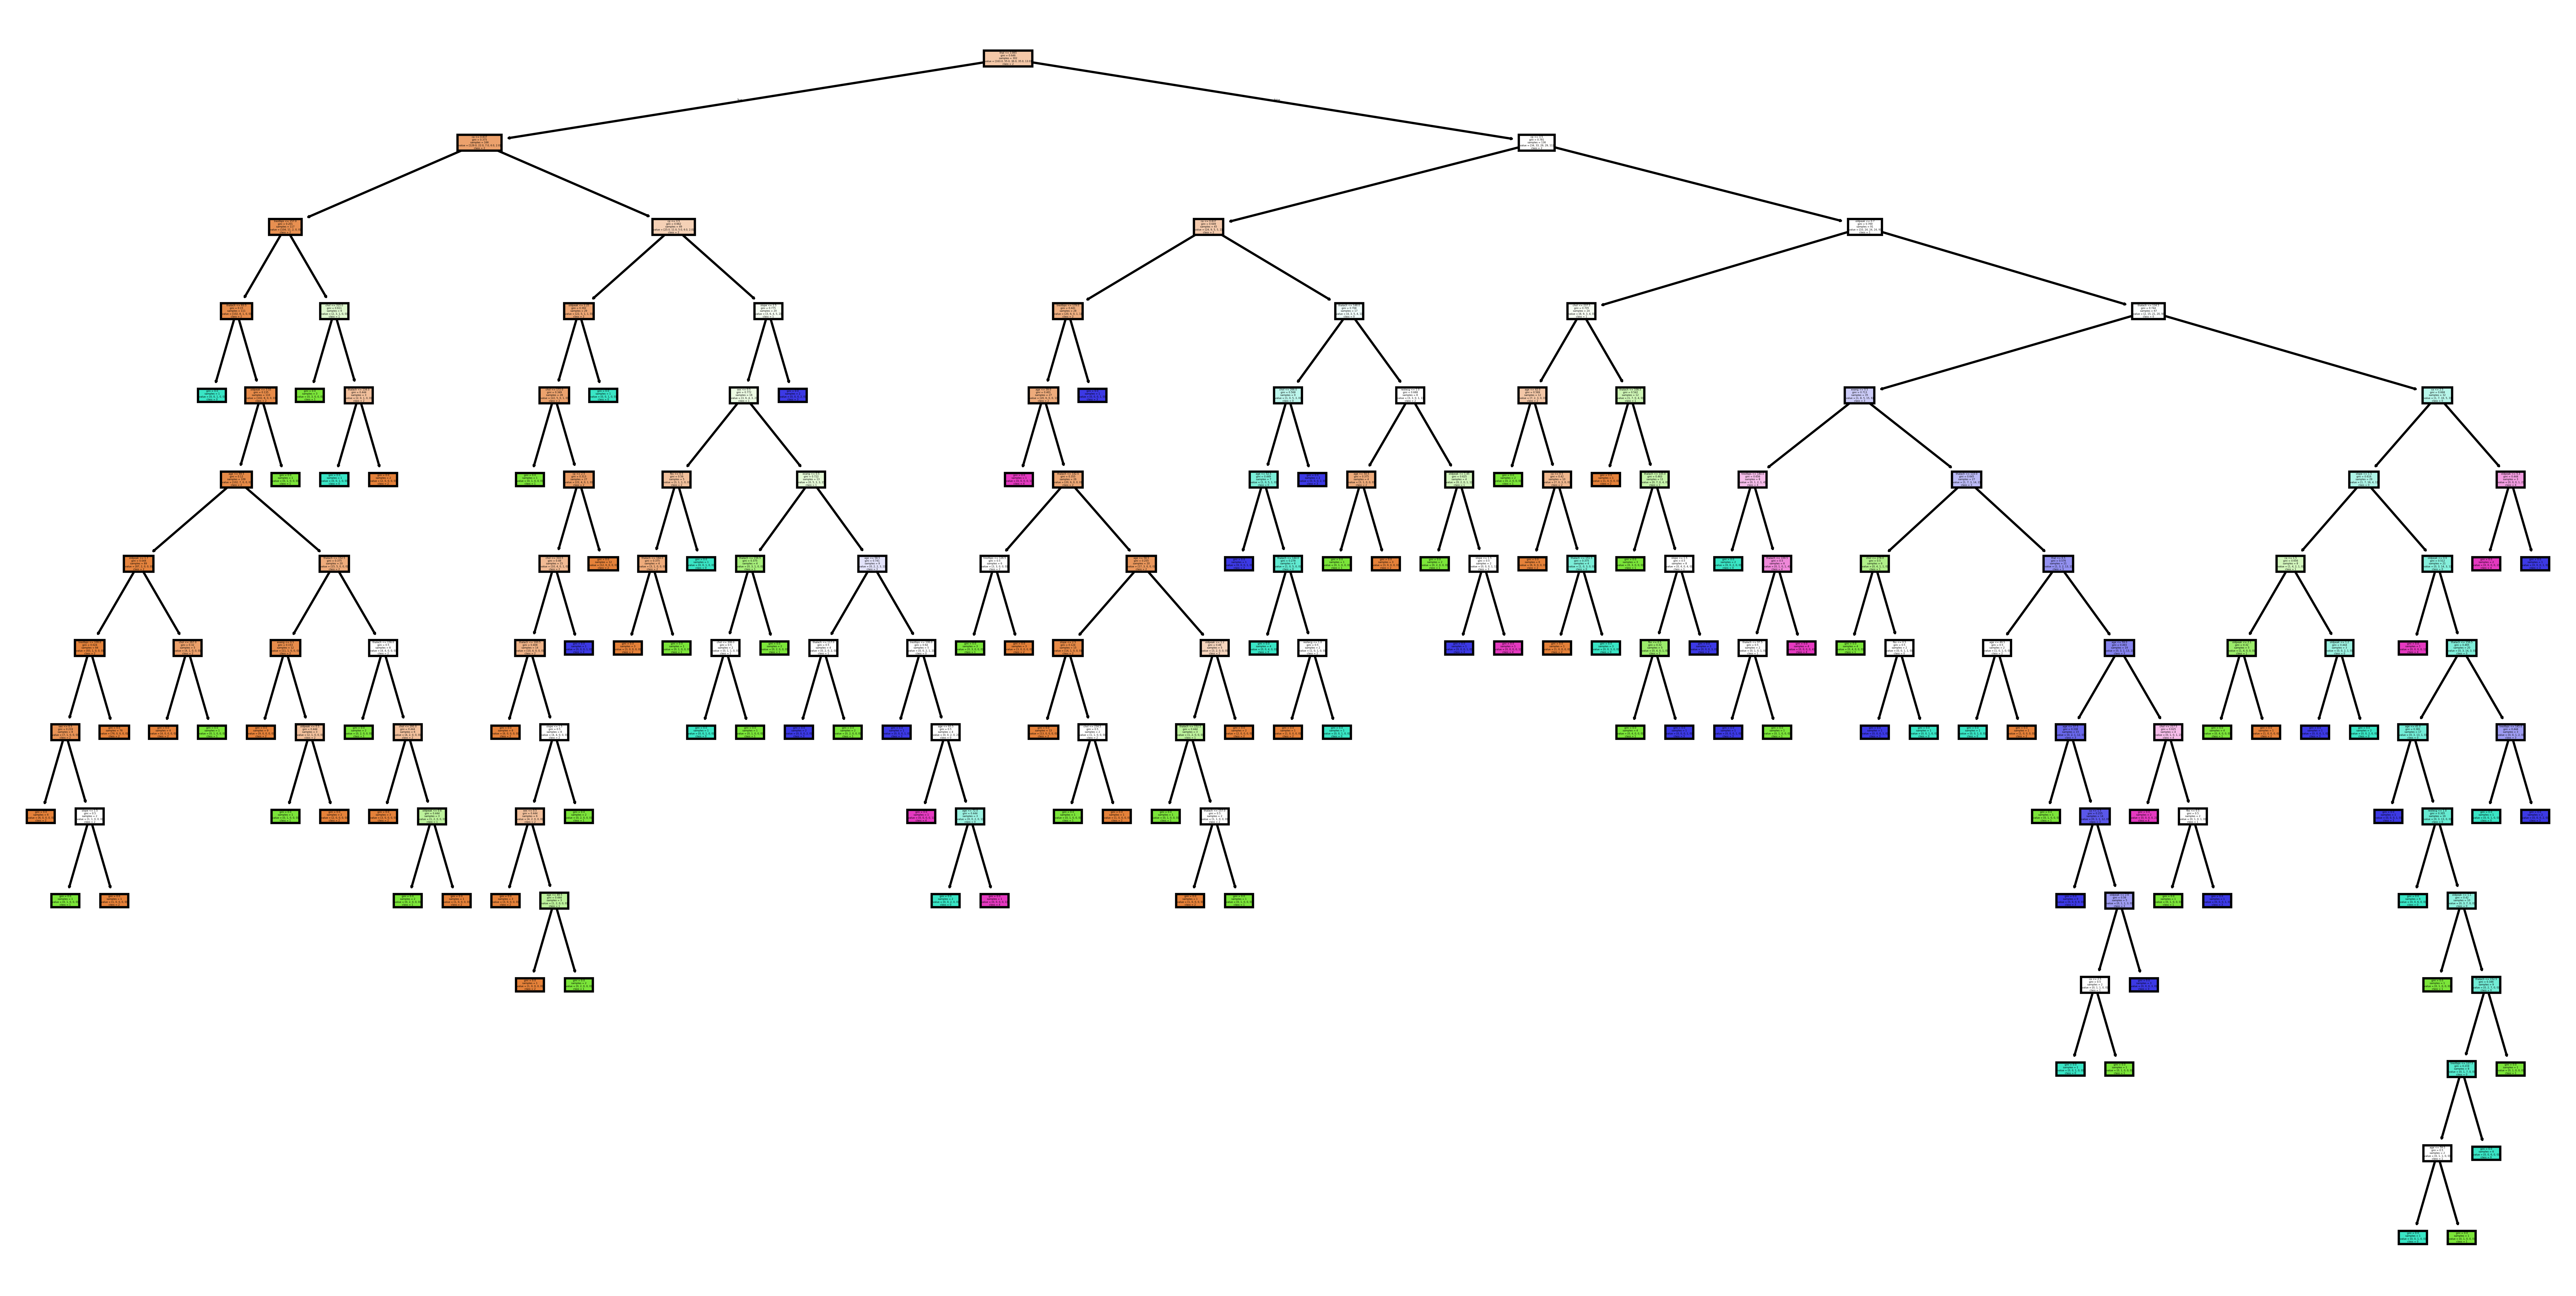

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10), dpi=600)
tree.plot_tree(model, feature_names=features, class_names=[str(x) for x in y.unique()], filled=True)
plt.show()